# ¿Cuál es la mejor tarifa?

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.

[Te proporcionamos algunos comentarios para orientarte mientras completas este proyecto. Pero debes asegurarte de eliminar todos los comentarios entre corchetes antes de entregar tu proyecto.]

[Antes de sumergirte en el análisis de datos, explica por tu propia cuenta el propósito del proyecto y las acciones que planeas realizar.]

[Ten en cuenta que estudiar, modificar y analizar datos es un proceso iterativo. Es normal volver a los pasos anteriores y corregirlos/ampliarlos para permitir nuevos pasos.]

## Inicialización

In [ ]:
# Cargar todas las librerías
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
from math import factorial
from scipy import stats as st
import math as mt

## Cargar datos

In [ ]:
# Carga los archivos de datos en diferentes DataFrames
users = pd.read_csv("/content/megaline_users.csv")
calls = pd.read_csv("/content/megaline_calls.csv")
messages = pd.read_csv("/content/megaline_messages.csv")
internet = pd.read_csv("/content/megaline_internet.csv")
plans = pd.read_csv("/content/megaline_plans.csv")

## Preparar los datos

[Los datos para este proyecto se dividen en varias tablas. Explora cada una para tener una comprensión inicial de los datos. Si es necesario, haz las correcciones requeridas en cada tabla.]

## Tarifas

In [ ]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 260.0+ bytes


In [ ]:
# Imprime una muestra de los datos para las tarifas
plans.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

Al revisar la información general y la muestra de datos del DataFrame plans, observamos que contiene los detalles de cada tarifa, incluyendo el número de mensajes, minutos, megabytes incluidos, costos mensuales y precios por unidad adicional.

No se encontraron valores ausentes ni tipos de datos incorrectos. Las columnas presentan los formatos adecuados.

Por lo tanto, no es necesario realizar ninguna modificación en este DataFrame, ya que los datos se encuentran limpios y correctamente estructurados para continuar con el análisis.



## Corregir datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [ ]:
#No hay errores en el DataFrame de Plans

## Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [ ]:
#No es necesario agregar nuevas columnas ni obtener valores adicionales en este DataFrame, ya que únicamente contiene la información base de los planes ofrecidos.
#Esto nos servira para obtener o hacer operaciones en otros DataFrames

## Usuarios/as

In [ ]:
# Imprime la información general/resumida sobre el DataFrame de usuarios
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [ ]:
# Imprime una muestra de datos para usuarios
users.sample(20)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
331,1331,Lashandra,Ramos,54,"Dallas-Fort Worth-Arlington, TX MSA",2018-02-06,surf,NaN
213,1213,Carl,Newman,47,"San Diego-Chula Vista-Carlsbad, CA MSA",2018-11-25,ultimate,NaN
426,1426,Lamont,Conner,44,"San Francisco-Oakland-Berkeley, CA MSA",2018-07-09,ultimate,NaN
133,1133,Larry,Barr,50,"Cincinnati, OH-KY-IN MSA",2018-07-21,ultimate,NaN
222,1222,Cleo,Anderson,18,"Los Angeles-Long Beach-Anaheim, CA MSA",2018-06-27,surf,NaN
159,1159,Dierdre,Baker,58,"Miami-Fort Lauderdale-West Palm Beach, FL MSA",2018-07-21,ultimate,NaN
18,1018,Dennis,Grimes,70,"Indianapolis-Carmel-Anderson, IN MSA",2018-10-17,surf,NaN
160,1160,Steven,Morgan,44,"Portland-Vancouver-Hillsboro, OR-WA MSA",2018-02-05,surf,NaN
446,1446,Pasquale,Ball,52,"Austin-Round Rock-Georgetown, TX MSA",2018-09-10,surf,NaN
142,1142,Charlesetta,Dillard,18,"New Orleans-Metairie, LA MSA",2018-08-23,surf,NaN


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

Al revisar la información proporcionada por las funciones info() y sample(), observamos que en la columna churn_date existen valores nulos. Esto se debe a que algunos usuarios aún están activos y no tienen registrada una fecha de baja, por lo que será necesario corregir estos valores antes de realizar el análisis.

Además, las columnas reg_date y churn_date se encuentran en formato object; por lo tanto, es necesario convertirlas al tipo datetime

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [ ]:
users["reg_date"] = pd.to_datetime(users["reg_date"])
users["churn_date"] = pd.to_datetime(users["churn_date"])

### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [ ]:
users["status"] = np.where(users["churn_date"].isna(), "Activo", "Dado de baja")
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     datetime64[ns]
 8   status      500 non-null    object        
dtypes: datetime64[ns](2), int64(2), object(5)
memory usage: 35.3+ KB


## Llamadas

In [ ]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas
calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [ ]:
# Imprime una muestra de datos para las llamadas
calls.sample(15)

,id,user_id,call_date,duration
60711,1220_62,1220,2018-12-20,5.66
55971,1201_69,1201,2018-08-01,19.25
112566,1397_136,1397,2018-10-07,5.14
79551,1284_1125,1284,2018-12-28,6.53
66167,1240_25,1240,2018-10-03,10.01
132535,1477_91,1477,2018-11-16,12.98
101608,1362_358,1362,2018-02-27,20.21
25990,1099_314,1099,2018-07-02,9.26
91179,1328_809,1328,2018-05-20,14.75
4423,1018_369,1018,2018-11-23,1.96


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

Al revisar la información general y la muestra de datos, se observa que los valores del DataFrame son correctos y no hay datos ausentes.
Sin embargo, la columna call_date tiene el tipo de dato object, por lo que es necesario convertirla al tipo datetime.
Esto permitirá realizar cálculos relacionados con fechas durante el análisis

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [ ]:
calls["call_date"] = pd.to_datetime(calls["call_date"])

### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [ ]:
calls["month"] = calls["call_date"].dt.month

## Mensajes

In [ ]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes
messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [ ]:
# Imprime una muestra de datos para los mensajes
messages.sample(15)

,id,user_id,message_date
3391,1036_226,1036,2018-10-16
49689,1328_647,1328,2018-09-30
57963,1365_119,1365,2018-08-26
63178,1401_124,1401,2018-11-27
72891,1470_519,1470,2018-10-05
4532,1043_878,1043,2018-07-21
69492,1451_189,1451,2018-08-28
37801,1250_54,1250,2018-10-27
74908,1487_49,1487,2018-12-23
40372,1260_418,1260,2018-12-22


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

Al igual que en el anterior DataFrame al revisar la información general y la muestra de datos, se observa que los valores del DataFrame son correctos y no hay datos ausentes. Sin embargo, la columna message_date tiene el tipo de dato object, por lo que es necesario convertirla al tipo datetime.

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [ ]:
messages["message_date"] = pd.to_datetime(messages["message_date"])

### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [ ]:
messages["month"] = messages["message_date"].dt.month

## Internet

In [ ]:
# Imprime la información general/resumida sobre el DataFrame de internet
internet.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [ ]:
# Imprime una muestra de datos para el tráfico de internet
internet.sample(15)


,id,user_id,session_date,mb_used
75333,1354_265,1354,2018-09-02,625.92
20385,1095_20,1095,2018-05-03,210.72
50761,1226_242,1226,2018-09-20,302.39
23914,1110_172,1110,2018-07-25,491.94
56186,1254_119,1254,2018-08-21,24.45
74181,1347_276,1347,2018-09-24,404.56
38913,1174_176,1174,2018-07-17,422.04
8841,1046_126,1046,2018-08-03,588.70
32791,1147_438,1147,2018-06-16,613.76
8843,1046_128,1046,2018-07-27,423.35


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

Al igual que en el anterior DataFrame al revisar la información general y la muestra de datos, se observa que los valores del DataFrame son correctos y no hay datos ausentes. Sin embargo, la columna session_date tiene el tipo de dato object, por lo que es necesario convertirla al tipo datetime.

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [ ]:
internet["session_date"] = pd.to_datetime(internet["session_date"])

### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [ ]:
internet["month"] = internet["session_date"].dt.month

## Estudiar las condiciones de las tarifas

[Es sumamente importante entender cómo funcionan las tarifas, cómo se les cobra a los usuarios en función de su plan de suscripción. Así que te sugerimos imprimir la información de la tarifa para ver una vez más sus condiciones.]

In [ ]:
# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras
plans.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


## Agregar datos por usuario

[Ahora que los datos están limpios, agrega los datos por usuario y por periodo para que solo haya un registro por usuario y por periodo. Esto facilitará mucho el análisis posterior.]

In [ ]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.
calls_per_month = calls.groupby(['user_id', 'month'])['id'].count()
calls_per_month = calls_per_month.rename('calls_count').reset_index()
calls_per_month.head(15)

,user_id,month,calls_count
0,1000,12,16
1,1001,8,27
2,1001,9,49
3,1001,10,65
4,1001,11,64
5,1001,12,56
6,1002,10,11
7,1002,11,55
8,1002,12,47
9,1003,12,149


In [ ]:
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.
calls_per_min_duration = calls.groupby(["user_id", "month"])["duration"].sum()
calls_per_min_duration = calls_per_min_duration.rename("Min_use").reset_index()
calls_per_min_duration.head(15)

,user_id,month,Min_use
0,1000,12,116.83
1,1001,8,171.14
2,1001,9,297.69
3,1001,10,374.11
4,1001,11,404.59
5,1001,12,392.93
6,1002,10,54.13
7,1002,11,359.76
8,1002,12,363.24
9,1003,12,1041.00


In [ ]:
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.
messages_per_month = messages.groupby(["user_id", "month"])["id"].count()
messages_per_month = messages_per_month.rename("Messages_per_month").reset_index()
messages_per_month.head(15)

,user_id,month,Messages_per_month
0,1000,12,11
1,1001,8,30
2,1001,9,44
3,1001,10,53
4,1001,11,36
5,1001,12,44
6,1002,10,15
7,1002,11,32
8,1002,12,41
9,1003,12,50


In [ ]:
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.
internet_per_month = internet.groupby(["user_id", "month"])["mb_used"].sum()
internet_per_month = internet_per_month.rename("Internet_per_month").reset_index()
internet_per_month.head(15)

,user_id,month,Internet_per_month
0,1000,12,1901.47
1,1001,8,6919.15
2,1001,9,13314.82
3,1001,10,22330.49
4,1001,11,18504.30
5,1001,12,19369.18
6,1002,10,6552.01
7,1002,11,19345.08
8,1002,12,14396.24
9,1003,12,27044.14


[Junta los datos agregados en un DataFrame para que haya un registro que represente lo que consumió un usuario único en un mes determinado.]

In [ ]:
# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month
Register_per_user = calls_per_month
Register_per_user = Register_per_user.merge(calls_per_min_duration, on=["user_id", "month"], how="outer")
Register_per_user = Register_per_user.merge(messages_per_month, on=["user_id", "month"], how="outer")
Register_per_user = Register_per_user.merge(internet_per_month, on=["user_id", "month"], how="outer")
Register_per_user.head(15)

,user_id,month,calls_count,Min_use,Messages_per_month,Internet_per_month
0,1000,12,16.0,116.83,11.0,1901.47
1,1001,8,27.0,171.14,30.0,6919.15
2,1001,9,49.0,297.69,44.0,13314.82
3,1001,10,65.0,374.11,53.0,22330.49
4,1001,11,64.0,404.59,36.0,18504.30
5,1001,12,56.0,392.93,44.0,19369.18
6,1002,10,11.0,54.13,15.0,6552.01
7,1002,11,55.0,359.76,32.0,19345.08
8,1002,12,47.0,363.24,41.0,14396.24
9,1003,12,149.0,1041.00,50.0,27044.14


In [ ]:
# Añade la información de la tarifa
Register_per_user = Register_per_user.merge(users[["user_id", "plan"]], on="user_id", how="outer")
Register_per_user = Register_per_user.merge(plans, left_on="plan", right_on="plan_name", how="outer")
print(Register_per_user.head())


   user_id  month  calls_count  Min_use  Messages_per_month  \
0     1001    8.0         27.0   171.14                30.0   
1     1001    9.0         49.0   297.69                44.0   
2     1001   10.0         65.0   374.11                53.0   
3     1001   11.0         64.0   404.59                36.0   
4     1001   12.0         56.0   392.93                44.0   

   Internet_per_month  plan  messages_included  mb_per_month_included  \
0             6919.15  surf                 50                  15360   
1            13314.82  surf                 50                  15360   
2            22330.49  surf                 50                  15360   
3            18504.30  surf                 50                  15360   
4            19369.18  surf                 50                  15360   

   minutes_included  usd_monthly_pay  usd_per_gb  usd_per_message  \
0               500               20          10             0.03   
1               500               20        

[Calcula los ingresos mensuales por usuario (resta el límite del paquete gratuito del número total de llamadas, mensajes de texto y datos; multiplica el resultado por el valor del plan de llamadas; añade la tarifa mensual en función del plan de llamadas). Nota: Dadas las condiciones del plan, ¡esto podría no ser tan trivial como un par de líneas! Así que no pasa nada si dedicas algo de tiempo a ello.]

In [ ]:
# Calcula el ingreso mensual para cada usuario
cost_minutes = (Register_per_user["Min_use"] - Register_per_user["minutes_included"]).clip(lower=0)
cost_messages = (Register_per_user["Messages_per_month"] - Register_per_user["messages_included"]).clip(lower=0)
cost_gb = (Register_per_user["Internet_per_month"] - Register_per_user["mb_per_month_included"]).clip(lower=0)
cost_gb = (cost_gb / 1024)
Register_per_user["Montly-revenue"] = (Register_per_user['usd_monthly_pay'] + cost_minutes * Register_per_user['usd_per_minute'] + cost_messages * Register_per_user['usd_per_message'] + cost_gb * Register_per_user['usd_per_gb'])
Register_per_user.head()

,user_id,month,calls_count,Min_use,Messages_per_month,Internet_per_month,plan,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,Montly-revenue
0,1001,8.0,27.0,171.14,30.0,6919.15,surf,50,15360,500,20,10,0.03,0.03,surf,20.000000
1,1001,9.0,49.0,297.69,44.0,13314.82,surf,50,15360,500,20,10,0.03,0.03,surf,20.000000
2,1001,10.0,65.0,374.11,53.0,22330.49,surf,50,15360,500,20,10,0.03,0.03,surf,88.161191
3,1001,11.0,64.0,404.59,36.0,18504.30,surf,50,15360,500,20,10,0.03,0.03,surf,50.706055
4,1001,12.0,56.0,392.93,44.0,19369.18,surf,50,15360,500,20,10,0.03,0.03,surf,59.152148


## Estudia el comportamiento de usuario

[Calcula algunas estadísticas descriptivas para los datos agregados y fusionados que nos sean útiles y que muestren un panorama general captado por los datos. Dibuja gráficos útiles para facilitar la comprensión. Dado que la tarea principal es comparar las tarifas y decidir cuál es más rentable, las estadísticas y gráficas deben calcularse por tarifa.]

[En los comentarios hallarás pistas relevantes para las llamadas, pero no las hay para los mensajes e Internet. Sin embargo, el principio del estudio estadístico que se aplica para ellos es el mismo que para las llamadas.]

### Llamadas

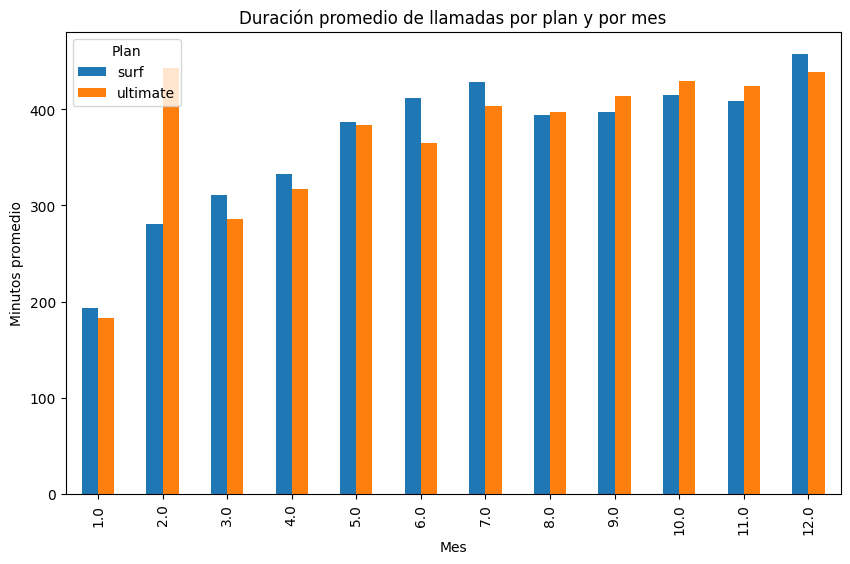

In [ ]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.
Values = Register_per_user.groupby(["plan_name", "month"])["Min_use"].mean().reset_index()
pivoted = Values.pivot(index="month", columns="plan_name", values="Min_use")
pivoted.plot(kind="bar",
            title="Duración promedio de llamadas por plan y por mes",
            figsize=(10, 6)
)

plt.xlabel("Mes")
plt.ylabel("Minutos promedio")
plt.legend(title="Plan")

plt.show()


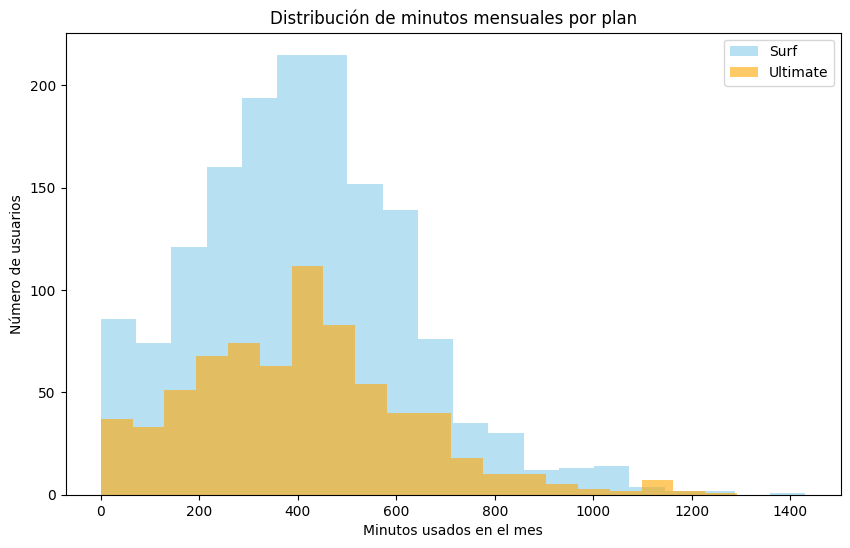

In [ ]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.
surf_minutes = Register_per_user[Register_per_user['plan_name'] == 'surf']['Min_use']
ultimate_minutes = Register_per_user[Register_per_user['plan_name'] == 'ultimate']['Min_use']

plt.figure(figsize=(10, 6))
plt.hist(surf_minutes, bins=20, alpha=0.6, label='Surf', color='skyblue')
plt.hist(ultimate_minutes, bins=20, alpha=0.6, label='Ultimate', color='orange')
plt.title('Distribución de minutos mensuales por plan')
plt.xlabel('Minutos usados en el mes')
plt.ylabel('Número de usuarios')
plt.legend()
plt.show()

[Calcula la media y la variable de la duración de las llamadas para averiguar si los usuarios de los distintos planes se comportan de forma diferente al realizar sus llamadas.]

In [ ]:
# Calcula la media y la varianza de la duración mensual de llamadas.
media_llamadas = Register_per_user['Min_use'].mean()
var_llamadas = Register_per_user['Min_use'].var()

print(f"Media de duración mensual de llamadas: {media_llamadas:.2f} minutos")
print(f"Varianza de duración mensual de llamadas: {var_llamadas:.2f}")


Media de duración mensual de llamadas: 411.49 minutos
Varianza de duración mensual de llamadas: 48088.30


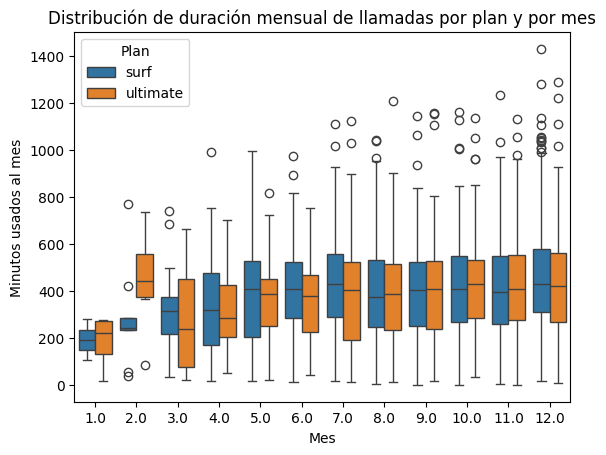

In [ ]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas
sns.boxplot(data=Register_per_user, x='month', y='Min_use', hue='plan_name')

plt.title('Distribución de duración mensual de llamadas por plan y por mes')
plt.xlabel('Mes')
plt.ylabel('Minutos usados al mes')
plt.legend(title='Plan')

plt.show()



[Elabora las conclusiones sobre el comportamiento de los usuarios con respecto a las llamadas. ¿Su comportamiento varía en función del plan?]

El comportamiento varía según el plan. Los usuarios del plan Ultimate tienden a usar más minutos mensuales que los del plan Surf. El diagrama de caja muestra que los usuarios de Ultimate tienen una distribución más amplia, con valores más altos y menos restricciones.

En cambio, los usuarios de Surf presentan una distribución más concentrada y limitada, probablemente porque exceder el límite implica costos adicionales.

### Mensajes

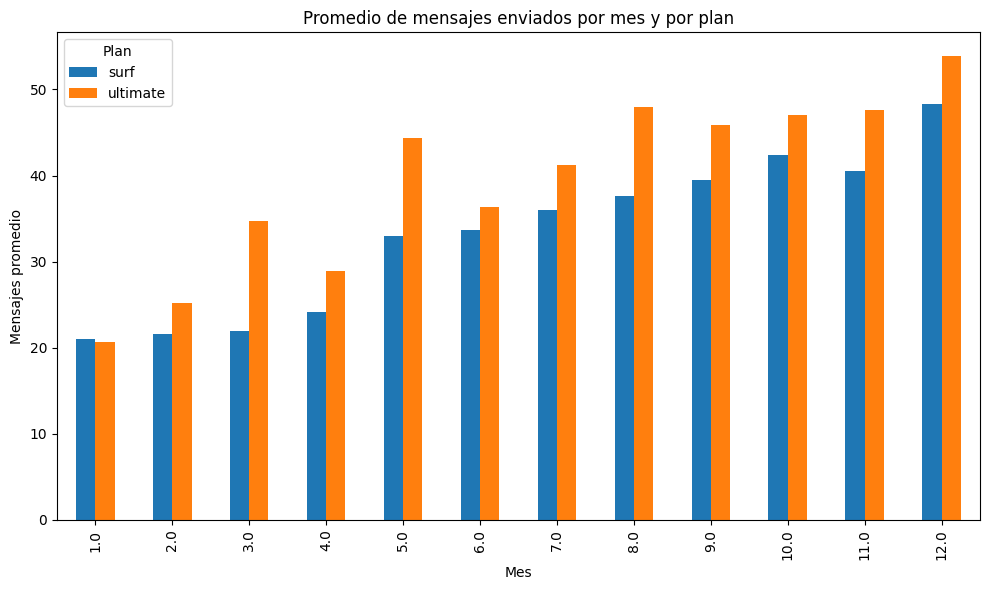

In [ ]:
# Comprara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan
msg_avg = Register_per_user.groupby(['plan_name', 'month'])['Messages_per_month'].mean().reset_index()
msg_pivot = msg_avg.pivot(index='month', columns='plan_name', values='Messages_per_month')

msg_pivot.plot(kind='bar', figsize=(10, 6), title='Promedio de mensajes enviados por mes y por plan')

plt.xlabel('Mes')
plt.ylabel('Mensajes promedio')
plt.legend(title='Plan')
plt.tight_layout()
plt.show()

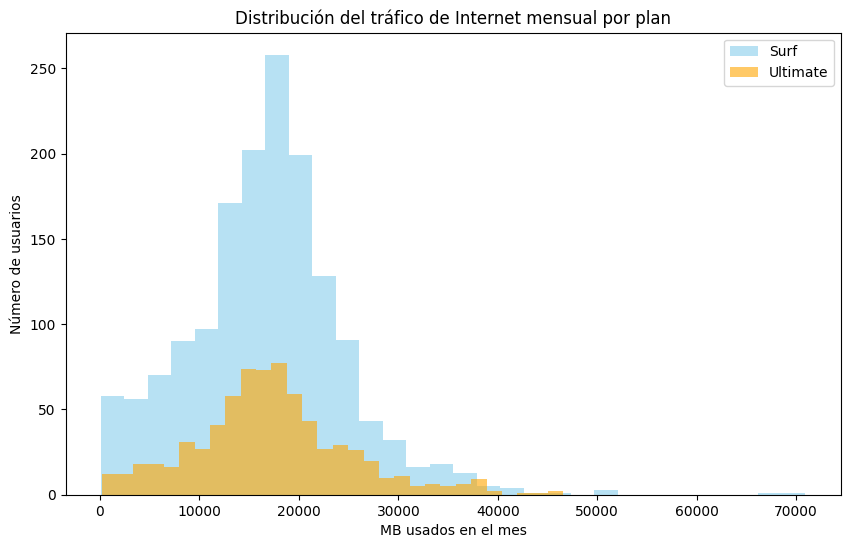

In [ ]:
# Compara la cantidad de tráfico de Internet consumido por usuarios por plan
surf_data = Register_per_user[Register_per_user['plan_name'] == 'surf']['Internet_per_month']
ultimate_data = Register_per_user[Register_per_user['plan_name'] == 'ultimate']['Internet_per_month']

plt.figure(figsize=(10, 6))
plt.hist(surf_data, bins=30, alpha=0.6, label='Surf', color='skyblue')
plt.hist(ultimate_data, bins=30, alpha=0.6, label='Ultimate', color='orange')

plt.title('Distribución del tráfico de Internet mensual por plan')
plt.xlabel('MB usados en el mes')
plt.ylabel('Número de usuarios')
plt.legend()

plt.show()


[Elabora las conclusiones sobre el comportamiento de los usuarios con respecto a los mensajes. ¿Su comportamiento varía en función del plan?]

Sí, el comportamiento de los usuarios con respecto al envío de mensajes varía según el plan contratado. Los usuarios del plan Ultimate tienden a enviar más mensajes que los del plan Surf.

### Internet

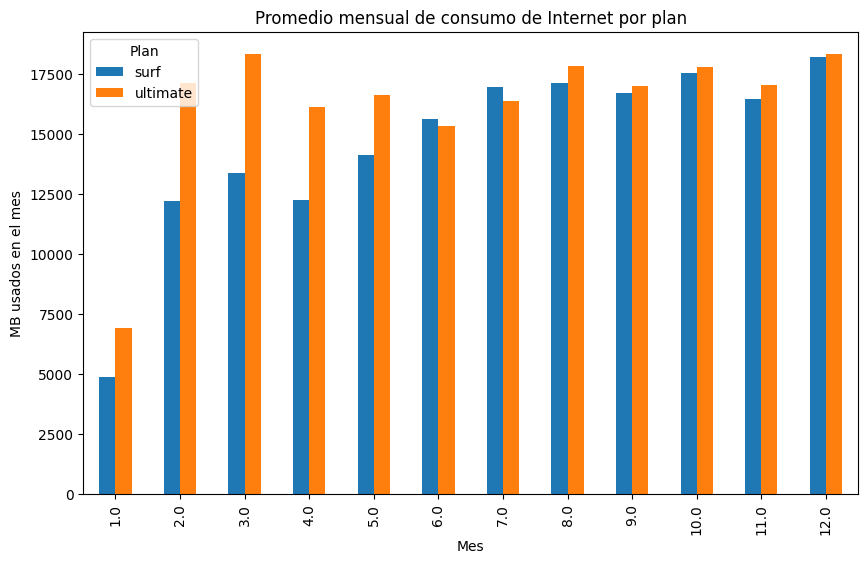

In [ ]:
#Promedio mensual de consumo de Internet por plan
internet_avg = Register_per_user.groupby(['plan_name', 'month'])['Internet_per_month'].mean().reset_index()

internet_pivot = internet_avg.pivot(index='month', columns='plan_name', values='Internet_per_month')

internet_pivot.plot(kind='bar', figsize=(10, 6), title='Promedio mensual de consumo de Internet por plan')
plt.xlabel('Mes')
plt.ylabel('MB usados en el mes')
plt.legend(title='Plan')
plt.show()

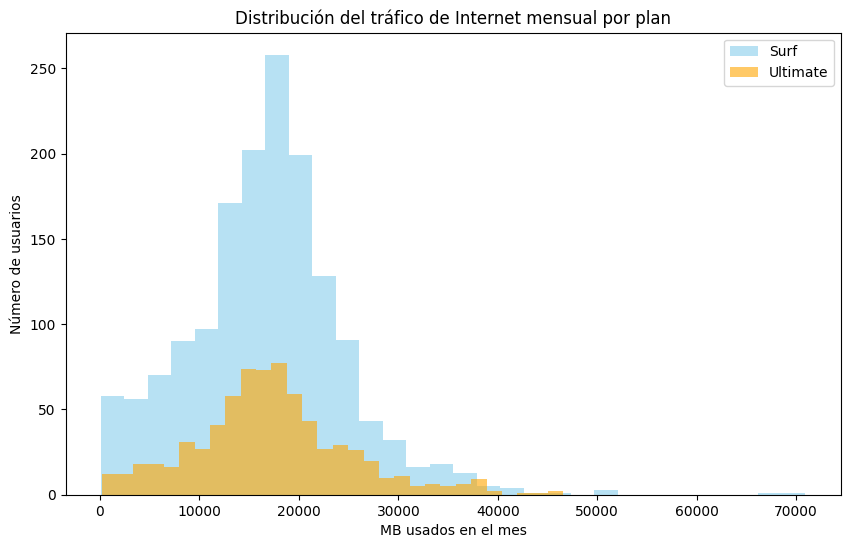

In [ ]:
#Distribución del consumo mensual por plan
surf_data = Register_per_user[Register_per_user['plan_name'] == 'surf']['Internet_per_month']
ultimate_data = Register_per_user[Register_per_user['plan_name'] == 'ultimate']['Internet_per_month']

plt.figure(figsize=(10, 6))
plt.hist(surf_data, bins=30, alpha=0.6, label='Surf', color='skyblue')
plt.hist(ultimate_data, bins=30, alpha=0.6, label='Ultimate', color='orange')
plt.title('Distribución del tráfico de Internet mensual por plan')
plt.xlabel('MB usados en el mes')
plt.ylabel('Número de usuarios')
plt.legend()
plt.show()


[Elabora las conclusiones sobre cómo los usuarios tienden a consumir el tráfico de Internet. ¿Su comportamiento varía en función del plan?]

La diferencia en el consumo de tráfico de Internet refleja cómo las condiciones de cada plan influyen en el comportamiento de los usuarios. Aquellos con planes que incluyen mayores beneficios (como el plan Ultimate) tienden a utilizar más recursos, mientras que quienes enfrentan cargos adicionales por excedente (como en el plan Surf) moderan su uso para evitar costos extra.

## Ingreso

[Del mismo modo que has estudiado el comportamiento de los usuarios, describe estadísticamente los ingresos de los planes.]

In [ ]:
# Agrupar por plan y calcular estadísticas básicas
revenue_stats = Register_per_user.groupby("plan_name")["Montly-revenue"].agg(["mean", "median", "var", "std", "min", "max", "count"]).round(2)
print(revenue_stats)

            mean  median      var    std   min     max  count
plan_name                                                    
surf       56.88   36.84  2686.17  51.83  20.0  581.33   1180
ultimate   72.06   70.00   109.88  10.48  70.0  178.52    579


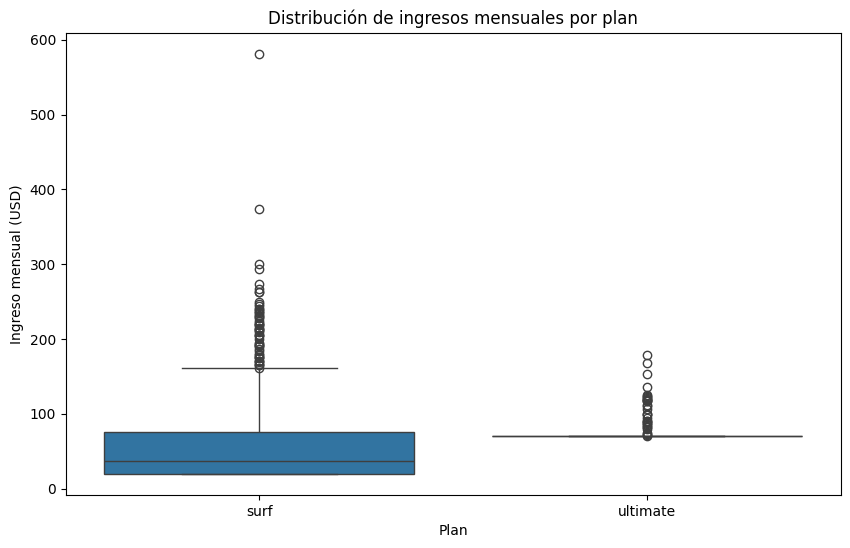

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=Register_per_user, x="plan_name", y="Montly-revenue")
plt.title("Distribución de ingresos mensuales por plan")
plt.xlabel("Plan")
plt.ylabel("Ingreso mensual (USD)")
plt.show()

[Elabora las conclusiones sobre cómo difiere el ingreso entre los planes.]

Este análisis sugiere que el plan Ultimate es más rentable por usuario en promedio, mientras que Surf depende más del comportamiento individual para generar ingresos adicionales.

## Prueba las hipótesis estadísticas

[Prueba la hipótesis de que son diferentes los ingresos promedio procedentes de los usuarios de los planes de llamada Ultimate y Surf.]

[Elabora las hipótesis nula y alternativa, escoge la prueba estadística, determina el valor alfa.]

In [ ]:
Values_per_city = Register_per_user.merge(users[['user_id', 'city']], on='user_id', how='left')

revenue_ny_nj = Values_per_city[Values_per_city['city'].str.contains('NY-NJ', na=False)]['Montly-revenue'].dropna()
revenue_other = Values_per_city[~Values_per_city['city'].str.contains('NY-NJ', na=False)]['Montly-revenue'].dropna()

alpha = 0.05

results = st.ttest_ind(revenue_ny_nj, revenue_other, equal_var=False)

print("p-value:", results.pvalue)
if results.pvalue < alpha:
    print("Rechazamos H₀: los ingresos promedio son significativamente diferentes.")
else:
    print("No se rechaza H₀: no hay diferencia significativa en los ingresos promedio.")

p-value: 0.002171579563127366
Rechazamos H₀: los ingresos promedio son significativamente diferentes.


[Prueba la hipótesis de que el ingreso promedio de los usuarios del área NY-NJ es diferente al de los usuarios de otras regiones.]

[Elabora las hipótesis nula y alternativa, escoge la prueba estadística, determina el valor alfa.]

In [ ]:
revenue_ny_nj = Values_per_city[Values_per_city['city'].str.contains('NY-NJ', na=False)]['Montly-revenue'].dropna()
revenue_other = Values_per_city[~Values_per_city['city'].str.contains('NY-NJ', na=False)]['Montly-revenue'].dropna()

alpha = 0.05

results = st.ttest_ind(revenue_ny_nj, revenue_other, equal_var=False)

print("p-value:", results.pvalue)
if results.pvalue < alpha:
    print("Rechazamos H₀: los ingresos promedio son significativamente diferentes.")
else:
    print("No se rechaza H₀: no hay diferencia significativa en los ingresos promedio.")

p-value: 0.002171579563127366
Rechazamos H₀: los ingresos promedio son significativamente diferentes.


## Conclusión general

[En esta sección final, enumera tus conclusiones importantes. Asegúrate de que estas abarquen todas las decisiones (suposiciones) importantes que adoptaste y que determinaron la forma elegida para procesar y analizar los datos.]

En este análisis evaluamos el comportamiento de los usuarios dentro de los planes que ofrece la compañía Megaline, utilizando datos de 500 clientes durante el año 2018.

Antes de realizar cualquier operación o visualización, se verificó la calidad de los datos: se revisaron tipos de datos, valores nulos y se crearon las columnas necesarias para el análisis. Posteriormente, se construyó un nuevo DataFrame consolidado, integrando información de llamadas, mensajes, uso de internet y los planes para obtener una visión mensual completa de cada usuario.

Analisis de los datos que se obtuvieron:

Llamadas: Los usuarios del plan Ultimate tienden a usar más minutos en promedio, aunque la diferencia con respecto a Surf no siempre es drástica.

Mensajes: El plan Ultimate muestra un promedio ligeramente superior en cantidad de mensajes enviados. Un test estadístico confirmó que esta diferencia es significativa.

Internet: El consumo de datos también es mayor en Ultimate, lo que sugiere un perfil de usuario más activo y con mayor demanda digital.

Se realizaron pruebas estadísticas para comparar los ingresos promedio entre los planes Surf y Ultimate. Los resultados mostraron que las diferencias son estadísticamente significativas, siendo el plan Ultimate el más rentable.

Asimismo, se analizó si los ingresos promedio de los usuarios del área NY-NJ difieren de los de otras regiones. Los resultados también mostraron una diferencia significativa, lo que sugiere que la ubicación geográfica influye en la rentabilidad de los usuarios.

En general, los resultados indican que el plan Ultimate genera mayores ingresos y tiene usuarios con un uso más intensivo de los servicios. Además, se evidencia que las características demográficas y geográficas de los clientes pueden afectar su comportamiento de consumo y, en consecuencia, la rentabilidad para Megaline.
